# Assignment 6

## Imports && dataset

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
from torchvision.models import resnet18, ResNet18_Weights, mobilenet_v3_small, MobileNet_V3_Small_Weights
import matplotlib.pyplot as plt
import pandas as pd
# optional
import wandb

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
wandb.login()

True

In [3]:
weights = ResNet18_Weights.DEFAULT
preprocess = weights.transforms()

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=preprocess,
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=preprocess,
)

train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## Task 1 — Inspect and adapt pretrained TorchVision models (3 pts)

In this task, you will learn how TorchVision models are constructed and how to adapt them to CIFAR-10.

### Requirements


1. Load **two different pretrained image classification models** from `torchvision.models`.
   * At least one of them must be `resnet18`.
   * The second one can be `mobilenet_v3_small`, `efficientnet_b0`, `alexnet`, `resnet34`, `resnet50`, `resnet152`, or another comparable classification model from TorchVision.
2. For each model:
   * print the architecture,
   * identify where the final classifier layer is located,
   * determine the input dimension of the final classifier,
   * replace the final classifier so that the model outputs **10 logits**.
3. For each model, report:
   * total number of parameters,
   * name / location of the replaced classifier layer,
   * output shape for one mini-batch.
4. Run one mini-batch through each adapted model and verify that the output shape is:

$$
(B, 10)
$$


5. Briefly compare the two models:
   * where the classifier head is located,
   * how many parameters they have,
   * which model seems lighter / heavier,
   * what preprocessing is attached to the default pretrained weights.

## Required discussion

Explain:

* why the original classifier must be replaced,
* why pretrained models need their own preprocessing,
* why different architectures expose the final classifier in different places,
* which of the two models seems more convenient for CIFAR-10 on your hardware.

## Hint

For ResNet, the final layer is typically stored in `model.fc`. For AlexNet, MobileNet, and EfficientNet, the final layer is usually inside `model.classifier`.

In [4]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [6]:
model = resnet18(weights=weights)
num_features = 512
model.fc = nn.Linear(num_features, 10)
model = model.to(device)

print(model)
print("Total parameters:", count_parameters(model))
print("Trainable parameters:", count_trainable_parameters(model))

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [9]:
X_batch, y_batch = next(iter(train_loader))
preds = model(X_batch.to(device))
preds.shape

torch.Size([64, 10])

In [15]:
model = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights)
num_features = 1024
model.classifier[3] = nn.Linear(num_features, 10)
model = model.to(device)

print(model)
print("Total parameters:", count_parameters(model))
print("Trainable parameters:", count_trainable_parameters(model))

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [16]:
X_batch, y_batch = next(iter(train_loader))
preds = model(X_batch.to(device))
preds.shape

torch.Size([64, 10])

In [20]:
ResNet18_Weights.DEFAULT.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [19]:
MobileNet_V3_Small_Weights.DEFAULT.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

Briefly compare the two models:
* where the classifier head is located,
* how many parameters they have,
* which model seems lighter / heavier,
* what preprocessing is attached to the default pretrained weights.

RESNET:
* head -> model.fc
* parameter count -> 11181642
* heavier
* ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

MOBILENET:
* head -> model.classifier
* parameter count -> 1528106
* lighter
* the same

Explain:

* why the original classifier must be replaced,
* why pretrained models need their own preprocessing,
* why different architectures expose the final classifier in different places,
* which of the two models seems more convenient for CIFAR-10 on your hardware.



* we are using different dataset (1000 outputs vs 10 outputs)
* for the model to be effective we need to use the same preprocessing as the authors of the model did
* that is up to models architecture
* MobileNet seems more convenient, but the difference should be that big.

## Task 2 — Train a frozen-feature baseline on CIFAR-10 (3 pts)

Choose **one** of your adapted pretrained models from Task 1 and train it on CIFAR-10 as a **fixed feature extractor**.

In other words:

* keep the pretrained backbone frozen,
* train only the newly created classifier head.

This is the standard and simplest transfer-learning setup.

## Requirements


1. Load **CIFAR-10** and create a **train / validation** split.
2. Use the preprocessing corresponding to the selected weights.
3. Freeze the backbone and keep only the new classifier head trainable.
4. Train the model for at least **3 epochs**.
5. Use:
   * `CrossEntropyLoss`,
   * an optimizer of your choice from `torch.optim`.
6. Track:
   * training loss,
   * validation loss,
   * training accuracy,
   * validation accuracy.
7. Plot:
   * loss vs epoch,
   * accuracy vs epoch.
8. Report:
   * number of trainable parameters,
   * final validation accuracy.
9. **Strongly recommended:** log the experiment to **W&B**.

## Required explanation

Explain:

* what is frozen and what remains trainable,
* why this setup is called **transfer learning**,
* why this setup is cheaper than training the full model.

In [7]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)
num_features = 512
model.fc = nn.Linear(num_features, 10)
model = model.to(device)

In [10]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [ ]:
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
loss = torch.nn.CrossEntropyLoss()

In [15]:
epochs = 10
train_losses, val_losses, train_accs, val_accs = [], [], [], []

run = wandb.init(
    project="nn-assignment-6-2",
    config={"model": "resnet18", "epochs": epochs, "lr": 1e-3}
)

for epoch in range(epochs):
    model.train()
    epoch_train_loss, train_correct, train_total = 0.0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds = model(X_batch)
        l = loss(preds, y_batch)
        l.backward()
        optimizer.step()
        optimizer.zero_grad()

        epoch_train_loss += l.item() * X_batch.size(0)
        train_correct += (preds.argmax(dim=1) == y_batch).sum().item()
        train_total += y_batch.size(0)

    model.eval()
    epoch_val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            l = loss(preds, y_batch)

            epoch_val_loss += l.item() * X_batch.size(0)
            val_correct += (preds.argmax(dim=1) == y_batch).sum().item()
            val_total += y_batch.size(0)

    train_losses.append(epoch_train_loss / train_total)
    train_accs.append(train_correct / train_total)
    val_losses.append(epoch_val_loss / val_total)
    val_accs.append(val_correct / val_total)

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_losses[-1],
        "val_loss": val_losses[-1],
        "train_acc": train_accs[-1],
        "val_acc": val_accs[-1]
    })
    print(f"Epoch {epoch + 1}/{epochs} | train_loss={train_losses[-1]:.4f}, train_acc={train_accs[-1]:.4f}, val_loss={val_losses[-1]:.4f}, val_acc={val_accs[-1]:.4f}")

run.finish()


Epoch 1/10 | train_loss=1.2512, train_acc=0.6170, val_loss=0.8491, val_acc=0.7280
Epoch 2/10 | train_loss=0.7936, train_acc=0.7387, val_loss=0.7261, val_acc=0.7564
Epoch 3/10 | train_loss=0.7186, train_acc=0.7564, val_loss=0.6869, val_acc=0.7642
Epoch 4/10 | train_loss=0.6829, train_acc=0.7655, val_loss=0.6650, val_acc=0.7712
Epoch 5/10 | train_loss=0.6623, train_acc=0.7714, val_loss=0.6474, val_acc=0.7734
Epoch 6/10 | train_loss=0.6520, train_acc=0.7761, val_loss=0.6419, val_acc=0.7752
Epoch 7/10 | train_loss=0.6472, train_acc=0.7736, val_loss=0.6577, val_acc=0.7698
Epoch 8/10 | train_loss=0.6351, train_acc=0.7797, val_loss=0.6368, val_acc=0.7782
Epoch 9/10 | train_loss=0.6261, train_acc=0.7831, val_loss=0.6522, val_acc=0.7710
Epoch 10/10 | train_loss=0.6247, train_acc=0.7817, val_loss=0.6457, val_acc=0.7720


epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▁▆▇▇██████
train_loss,█▃▂▂▁▁▁▁▁▁
val_acc,▁▅▆▇▇█▇█▇▇
val_loss,█▄▃▂▁▁▂▁▂▁
epoch,10
train_acc,0.78169
train_loss,0.62466
val_acc,0.772
val_loss,0.64566


In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, label="train")
plt.plot(range(1, epochs + 1), val_losses, label="val")
plt.title("Loss vs epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), train_accs, label="train")
plt.plot(range(1, epochs + 1), val_accs, label="val")
plt.title("Accuracy vs epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
print(count_trainable_parameters(model))

In [ ]:
model.eval()
val_correct, val_total = 0, 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds = model(X_batch)

        val_correct += (preds.argmax(dim=1) == y_batch).sum().item()
        val_total += y_batch.size(0)
    print(f'Test accuracy: {val_correct/val_total:.4f}')

Explain:
* what is frozen and what remains trainable,
* why this setup is called transfer learning,
* why this setup is cheaper than training the full model.


* everything is frozen besides our last layer (feature extractor)
* we transfer trained weights to our model. also the learnt weights contain useful knowledge to this smaller task
* we only train last layer instead of the whole model

## Task 3 — Compare freezing vs fine-tuning (4 pts)

Use the **same model** as in Task 2 and compare two simple transfer-learning strategies:

### Model A — frozen backbone

* all pretrained backbone parameters frozen,
* only the new classifier head trainable.

### Model B — full fine-tuning

* all model parameters trainable.

Use the same:

* train / validation split,
* batch size,
* preprocessing,
* number of epochs.

You may use a smaller learning rate for the fine-tuned model.

## Requirements


1. Train both settings.
2. For each setting, report:
   * number of trainable parameters,
   * final validation loss,
   * final validation accuracy.
3. Create one final comparison table with:
   * model setting,
   * trainable parameters,
   * final validation accuracy.
4. Plot validation accuracy for both settings.
5. **Strongly recommended:** track both runs in **W&B**.

## Required discussion

Discuss:

* which setup worked better,
* whether fine-tuning improved the result enough to justify the extra training cost,
* which setup you would choose in practice.

## Practical note

If training on the full dataset is too slow on your hardware, you may use a **smaller subset** of CIFAR-10. In that case:

* clearly state the subset size,
* use exactly the same subset for both compared settings,
* keep the comparison fair.

In [20]:
model_A = resnet18(weights=ResNet18_Weights.DEFAULT)
num_features = 512
model_A.fc = nn.Linear(num_features, 10)
model_A = model_A.to(device)

for param in model_A.parameters():
    param.requires_grad = False

for param in model_A.fc.parameters():
    param.requires_grad = True

params_A = count_trainable_parameters(model_A)
print(f"Trainable parameters (Model A): {params_A}")

epochs = 10
optimizer_A = optim.Adam(model_A.fc.parameters(), lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()

train_losses_A, val_losses_A, train_accs_A, val_accs_A = [], [], [], []

run_A = wandb.init(
    project="nn-assignment-6",
    config={"model": "resnet18-frozen", "epochs": epochs, "lr": 1e-3}
)

for epoch in range(epochs):
    model_A.train()
    epoch_train_loss, train_correct, train_total = 0.0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds = model_A(X_batch)
        l = loss_fn(preds, y_batch)
        l.backward()
        optimizer_A.step()
        optimizer_A.zero_grad()

        epoch_train_loss += l.item() * X_batch.size(0)
        train_correct += (preds.argmax(dim=1) == y_batch).sum().item()
        train_total += y_batch.size(0)

    model_A.eval()
    epoch_val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model_A(X_batch)
            l = loss_fn(preds, y_batch)

            epoch_val_loss += l.item() * X_batch.size(0)
            val_correct += (preds.argmax(dim=1) == y_batch).sum().item()
            val_total += y_batch.size(0)

    train_losses_A.append(epoch_train_loss / train_total)
    train_accs_A.append(train_correct / train_total)
    val_losses_A.append(epoch_val_loss / val_total)
    val_accs_A.append(val_correct / val_total)

    wandb.log({
        "epoch": epoch + 1,
        "train_loss_A": train_losses_A[-1],
        "val_loss_A": val_losses_A[-1],
        "train_acc_A": train_accs_A[-1],
        "val_acc_A": val_accs_A[-1]
    })
    print(f"Epoch {epoch + 1}/{epochs} | train_loss={train_losses_A[-1]:.4f}, train_acc={train_accs_A[-1]:.4f}, val_loss={val_losses_A[-1]:.4f}, val_acc={val_accs_A[-1]:.4f}")

run_A.finish()


Trainable parameters (Model A): 5130


Epoch 1/10 | train_loss=0.9338, train_acc=0.6947, val_loss=0.7074, val_acc=0.7558
Epoch 2/10 | train_loss=0.7004, train_acc=0.7606, val_loss=0.6824, val_acc=0.7590
Epoch 3/10 | train_loss=0.6704, train_acc=0.7686, val_loss=0.6429, val_acc=0.7722
Epoch 4/10 | train_loss=0.6490, train_acc=0.7781, val_loss=0.6474, val_acc=0.7744
Epoch 5/10 | train_loss=0.6394, train_acc=0.7778, val_loss=0.6439, val_acc=0.7696
Epoch 6/10 | train_loss=0.6359, train_acc=0.7793, val_loss=0.6414, val_acc=0.7790
Epoch 7/10 | train_loss=0.6244, train_acc=0.7820, val_loss=0.6481, val_acc=0.7750
Epoch 8/10 | train_loss=0.6300, train_acc=0.7808, val_loss=0.6329, val_acc=0.7770
Epoch 9/10 | train_loss=0.6201, train_acc=0.7841, val_loss=0.6425, val_acc=0.7732
Epoch 10/10 | train_loss=0.6161, train_acc=0.7860, val_loss=0.6268, val_acc=0.7780


epoch,▁▂▃▃▄▅▆▆▇█
train_acc_A,▁▆▇▇▇▇████
train_loss_A,█▃▂▂▂▁▁▁▁▁
val_acc_A,▁▂▆▇▅█▇▇▆█
val_loss_A,█▆▂▃▂▂▃▂▂▁
epoch,10
train_acc_A,0.78596
train_loss_A,0.61606
val_acc_A,0.778
val_loss_A,0.62679


In [21]:
model_B = resnet18(weights=ResNet18_Weights.DEFAULT)
model_B.fc = nn.Linear(512, 10)
model_B = model_B.to(device)

for param in model_B.parameters():
    param.requires_grad = True

params_B = count_trainable_parameters(model_B)
print(f"Trainable parameters (Model B): {params_B}")

optimizer_B = optim.Adam(model_B.parameters(), lr=1e-4)

train_losses_B, val_losses_B, train_accs_B, val_accs_B = [], [], [], []

run_B = wandb.init(
    project="nn-assignment-6",
    config={"model": "resnet18-finetuned", "epochs": epochs, "lr": 1e-4}
)

for epoch in range(epochs):
    model_B.train()
    epoch_train_loss, train_correct, train_total = 0.0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds = model_B(X_batch)
        l = loss_fn(preds, y_batch)
        l.backward()
        optimizer_B.step()
        optimizer_B.zero_grad()

        epoch_train_loss += l.item() * X_batch.size(0)
        train_correct += (preds.argmax(dim=1) == y_batch).sum().item()
        train_total += y_batch.size(0)

    model_B.eval()
    epoch_val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model_B(X_batch)
            l = loss_fn(preds, y_batch)

            epoch_val_loss += l.item() * X_batch.size(0)
            val_correct += (preds.argmax(dim=1) == y_batch).sum().item()
            val_total += y_batch.size(0)

    train_losses_B.append(epoch_train_loss / train_total)
    train_accs_B.append(train_correct / train_total)
    val_losses_B.append(epoch_val_loss / val_total)
    val_accs_B.append(val_correct / val_total)

    wandb.log({
        "epoch": epoch + 1,
        "train_loss_B": train_losses_B[-1],
        "val_loss_B": val_losses_B[-1],
        "train_acc_B": train_accs_B[-1],
        "val_acc_B": val_accs_B[-1]
    })
    print(f"Epoch {epoch + 1}/{epochs} | train_loss={train_losses_B[-1]:.4f}, train_acc={train_accs_B[-1]:.4f}, val_loss={val_losses_B[-1]:.4f}, val_acc={val_accs_B[-1]:.4f}")

run_B.finish()


Trainable parameters (Model B): 11181642


Epoch 1/10 | train_loss=0.3644, train_acc=0.8798, val_loss=0.2265, val_acc=0.9236
Epoch 2/10 | train_loss=0.1149, train_acc=0.9632, val_loss=0.2174, val_acc=0.9254
Epoch 3/10 | train_loss=0.0497, train_acc=0.9853, val_loss=0.1964, val_acc=0.9358
Epoch 4/10 | train_loss=0.0306, train_acc=0.9917, val_loss=0.1933, val_acc=0.9420
Epoch 5/10 | train_loss=0.0400, train_acc=0.9874, val_loss=0.2142, val_acc=0.9338
Epoch 6/10 | train_loss=0.0258, train_acc=0.9922, val_loss=0.2573, val_acc=0.9308
Epoch 7/10 | train_loss=0.0277, train_acc=0.9912, val_loss=0.1957, val_acc=0.9402
Epoch 8/10 | train_loss=0.0261, train_acc=0.9911, val_loss=0.2005, val_acc=0.9410
Epoch 9/10 | train_loss=0.0170, train_acc=0.9943, val_loss=0.2249, val_acc=0.9380
Epoch 10/10 | train_loss=0.0211, train_acc=0.9930, val_loss=0.2594, val_acc=0.9284


epoch,▁▂▃▃▄▅▆▆▇█
train_acc_B,▁▆▇███████
train_loss_B,█▃▂▁▁▁▁▁▁▁
val_acc_B,▁▂▆█▅▄▇█▆▃
val_loss_B,▅▄▁▁▃█▁▂▄█
epoch,10
train_acc_B,0.99302
train_loss_B,0.02109
val_acc_B,0.9284
val_loss_B,0.25941


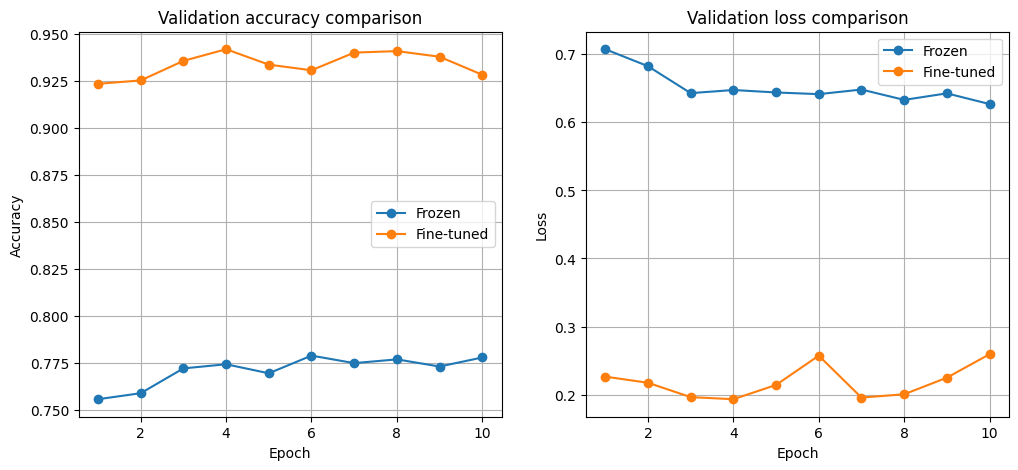

In [24]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), val_accs_A, marker="o", label="Frozen")
plt.plot(range(1, epochs + 1), val_accs_B, marker="o", label="Fine-tuned")
plt.title("Validation accuracy comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), val_losses_A, marker="o", label="Frozen")
plt.plot(range(1, epochs + 1), val_losses_B, marker="o", label="Fine-tuned")
plt.title("Validation loss comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [29]:
data = {
    "Model": ["Frozen", "Fine-tuned"],
    "Trainable params": [params_A, params_B],
    "Final val loss": [round(val_losses_A[-1], 4), round(val_losses_B[-1], 4)],
    "Final val accuracy": [round(val_accs_A[-1], 4), round(val_accs_B[-1], 4)]
}

pd.DataFrame(data)

,Model,Trainable params,Final val loss,Final val accuracy
0,Frozen,5130,0.6268,0.7780
1,Fine-tuned,11181642,0.2594,0.9284


Discuss:

* which setup worked better,
* whether fine-tuning improved the result enough to justify the extra training cost,
* which setup you would choose in practice.


* Fine-tuned
* Yes. 6.5min vs 10min.
* I would first do frozen layers to train our last layer and then maybe unfreeze everything.